# 1. Install Dependencies & Make a Request!
The ANTHROPIC_API_KEY value  is a secret key that we store in the .env file. We get the key from **Anthropic Console** online.

Make sure you use **git ignore** on the .env vile to prevent your secret key from being uploaded to github!

In [ ]:
# Load env variables
from dotenv import load_dotenv

load_dotenv()

In [ ]:
#Create API client
from anthropic import Anthropic

client = Anthropic()            #Create client using Anthropic package
model = "claude-sonnet-4-0"     #We'll be using the claude sonnet model

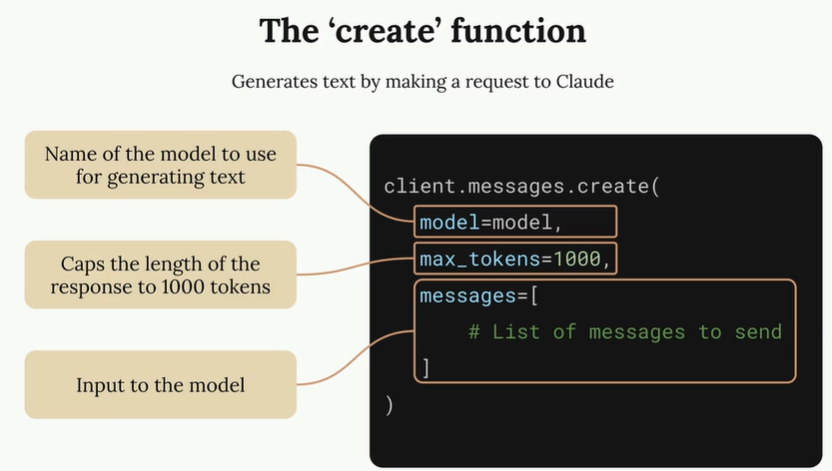
* Note that `max_tokens` is more of asaftey net so that Claude doesn't generate more content than is required. Adding a number to max tokens doesn't mean the model tries to target an output of that amount - it's just a cutoff. That's why it's a saftey net!

## Asking Claude something using the API

In [ ]:
# Make a request to the Claude API...
message = client.messagecreate(
    
    #add in the model, max tokens, and message so send
    model = model,
    max_tokens = 1000,
    messages = [{
        "role" : "user",
        "content" : "What is quantum computing? Anser in one sentence."
    }]
)


Executing the code above saves the API's response message in the `client` variable in a list, with a bunch of other variables. We can extract just the message from `client` as follows...

## Getting the API's Response Message

In [ ]:
message.content[0].text     #gives us just the generated text response from the API!

# 2. Multi-Turn Conversations

Naturally we might want to ask another question after our first one. How can we write another sentence to expand on a response.

But we need to understand something important first...

1. Messsage history is **never** STORED! If we were to ask another question, the response would be completely unrelated to our past conversation.
2. So, we need to always **append Claude's previous responses into our requests to the API** everytime we want a response. That way, we're getting a more contextual answer.

### Helper Functions for managing responses
We use **HELPER FUNCTIONS** to help us do this...

In [10]:
#This appends the old message to the message list
def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)                   

#This appends claude's ols message to the message list
def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)

#This function sends the messages to the API and returns the response as text
def chat(messages):
    message = client.messages.create(
        model=model,
        max_tokens=1000,
        messages=messages,
    )
    return message.content[0].text

## Conversation architecture

We use the helper functions above to make a proper conversation with recorded message history.

In [13]:
# Start with an empty message list to start with
messages = []

# Add the initial user question
add_user_message(messages, "Define quantum computing in one sentence") #add message text to the message list

# Get Claude's response
answer = chat(messages)

# Add Claude's response to the conversation history
add_assistant_message(messages, answer)

# Add a follow-up question
add_user_message(messages, "Write another sentence")

# Get the follow-up response with full context
final_answer = chat(messages)

NameError: name 'client' is not defined

# 3. Chatbot Exercise (Looping Chatbot)

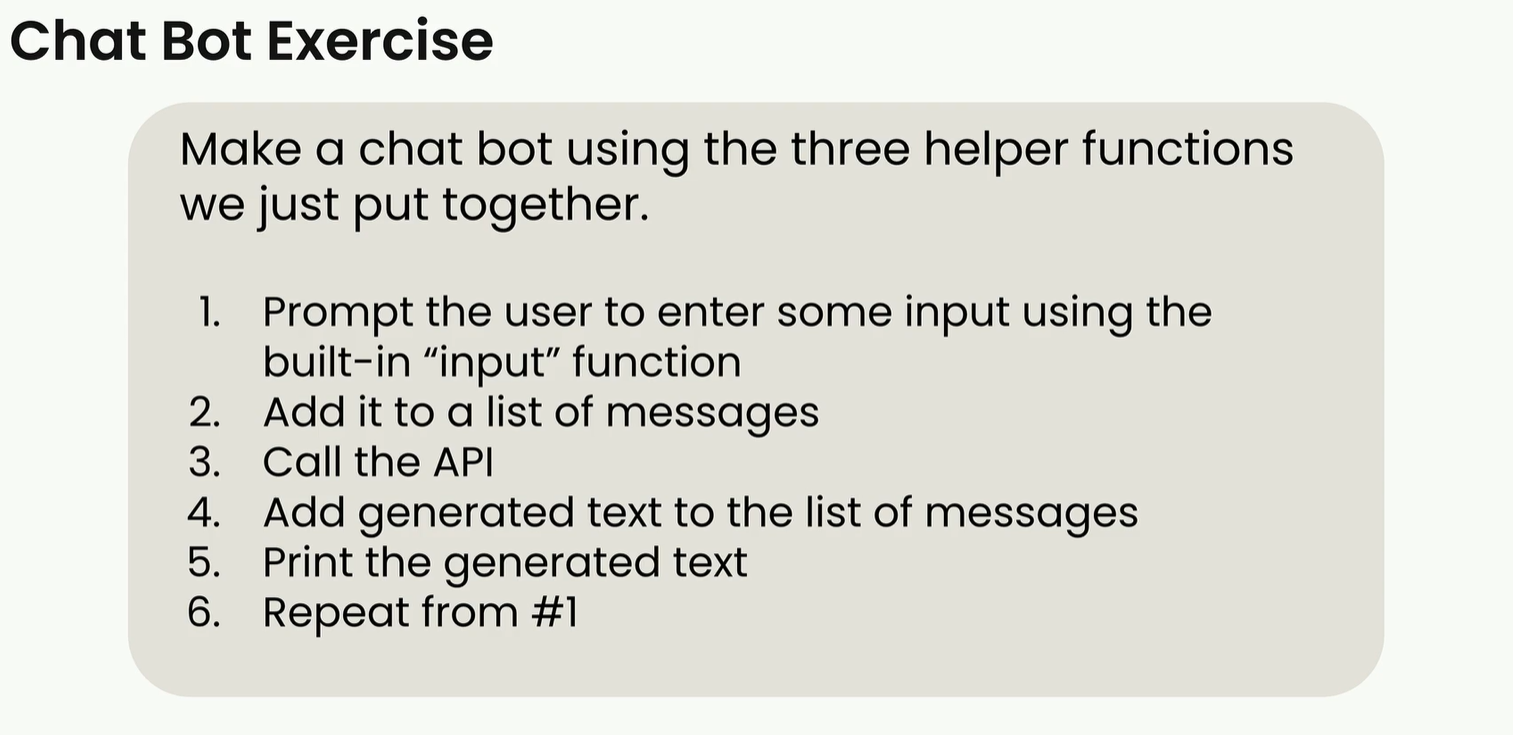

In [ ]:
#make an initial list of messages
messages = []

while True:
    # Get user input
    user_input = input("> ")
    print(">", user_input)
        
    # Add user message to the list of messages
    add_user_message(messages, user_input)
    
    # Add generated text to the list of messages
    answer = chat(messages)
    
    # Print Claude's response
    print("Claude:", answer)
    
    # Add Claude's response to the conversation history
    add_assistant_message(messages, answer)

# 4. System Prompts

System prompts provide Claude guidance on how to respond. It customizes Claude's tone and style of response. Claude responds in the way someone in a specified role would respond and it helps keep on task.

For example:
> `You are a patient math tutor. Do not directly answer a student's questions. Guide them to a solution step by step.`

**The first line of a system prompt will usually provide Claude a role. For example, "you are a patient math tutor"** so that the tutor guides to the solution, but doesn't just give everything away!

In [14]:
#pass in message list and system message to the chat function.
#returns the response as text
def chat(messages, system=None):

    #Set up the parameters for the API request
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
    }
    
    #If a system message is provided, add it to the parameters
    if system:
        params["system"] = system
    
    #Make the API request and return the response text
    message = client.messages.create(**params)
    return message.content[0].text

In [ ]:
messages = []

system = """
You are a patient math tutor.
Do not directly answer a student's questions.
Guide them to a solution step by step.
"""

add_user_message(messages, "How do I solve 5x+3=2 for x?")
answer = chat(messages)
answer

# 5. System Prompts Exercise

> Make the bot write back an answer to a message using a system prompt.

In [ ]:
messages = []

add_user_message(
    messages,
    "Write a python function that checks a string for duplicate characters.",
)

answer = chat(messages, system = "You're a python engineer who writes very concise code.") #Call chat function and pass in message history & system promp

NameError: name 'add_user_message' is not defined

In [ ]:
answer # print the value of answer.

Note that if we were to run this code without using a system promp, the answer is much longer. The system prompt gives us a better, more concise answer!

# 6. Temperature.
### How Claude Generates Text

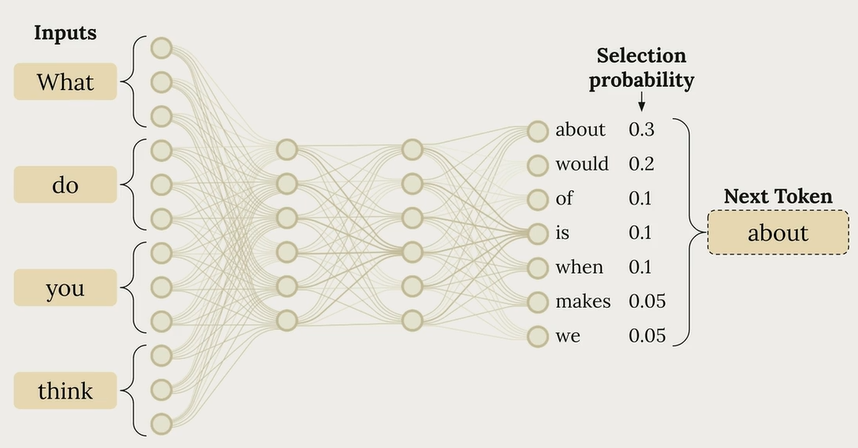

1. Claude breaks up our prompt into tokens. It goes through  prediction phase and predicts which words would likely come next and assigns a probability to each word.
2. Then in the sampling phase, a single token is selected given the probailities.
3. This process is repeated until we get the full message.

We can control the probabilities of certain outputs using something we call **temperature**.

* **Low temperature** creates a more deterministic output. It selects tokens that just have the highest probability.
* **High temperature** creates more random output

In general, when we want creative things, we want more temperature.

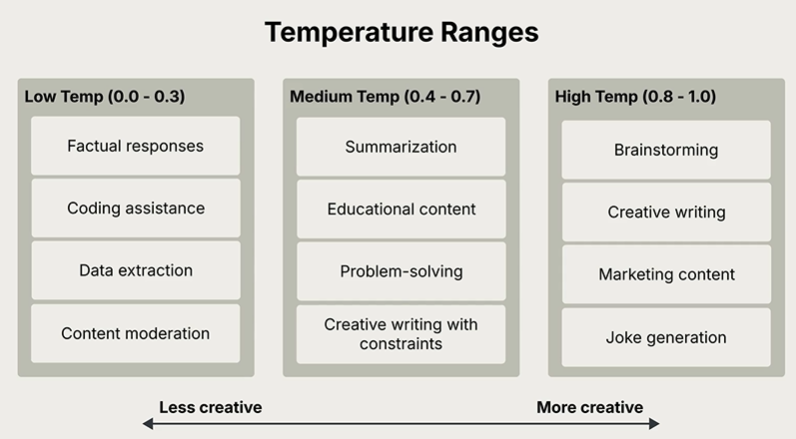

### Adding Temperature to our Conversation
Here is our new `chat()` function that uses `temperature` parameter.

In [ ]:
# In this chat function, we add a temperature parameter = 1.0 default
def chat(messages, system=None, temperature=1.0):
    
    # paramters object
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature
    }
    
    #If a system message is provided, add it to the parameters
    if system:
        params["system"] = system
    
    #Make the API request and return the response text
    message = client.messages.create(**params)
    return message.content[0].text

Now let's use this function by giving it a system prompt.

In [ ]:
messages = []

# Add a user message to the list with this new system prompt
add_user_message(
    messages,
    "generate a one sentence movie idea",
)

#call the chat function with a temperature of 0.0 to get a more deterministic response
answer = chat(messages, temperature = 1.0)  

answer # print the value of answer.

This is interesting! Increasing our temperature value when we call `chat()` gives us more creative ideas. Keeping it at `0` gives us largely the same response every time.

# 7. Response Streaming

1. When building chat applications with Claude, there's a significant user experience challenge: **responses can take 10-30 seconds to generate, leaving users staring at a loading spinner.** 
2. The solution is **response streaming**, which lets users see text appear chunk by chunk as Claude generates it, creating a much more responsive feel.

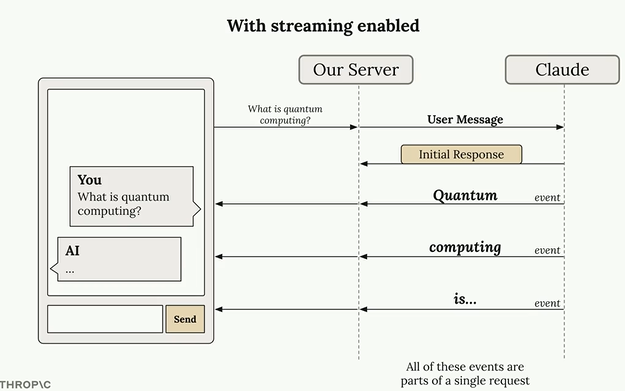

**using the very same helper functions from the beginning...**
We're going to change up our `chat()` function a bit to help us with response streaming.

In [ ]:
messages = []

add_user_message(messages, "Write a 1 sentence description of a fake database")

client.messages.create(
    model = model,
    max_tokens = 1000,
    messages = messages,
    stream=True
)

for event in stream:
    print(event)

NameError: name 'add_user_message' is not defined

The output of this is a bunch of `events`, each with their own meaning.

* **But the event that we care about the most is** `RawContentBlockDeltaEvent`

This contains the actual text that Claude generates and sends back to us chunk by chunk. We get a sequence of content block deltas and we repeatedly send extracted text back to display.

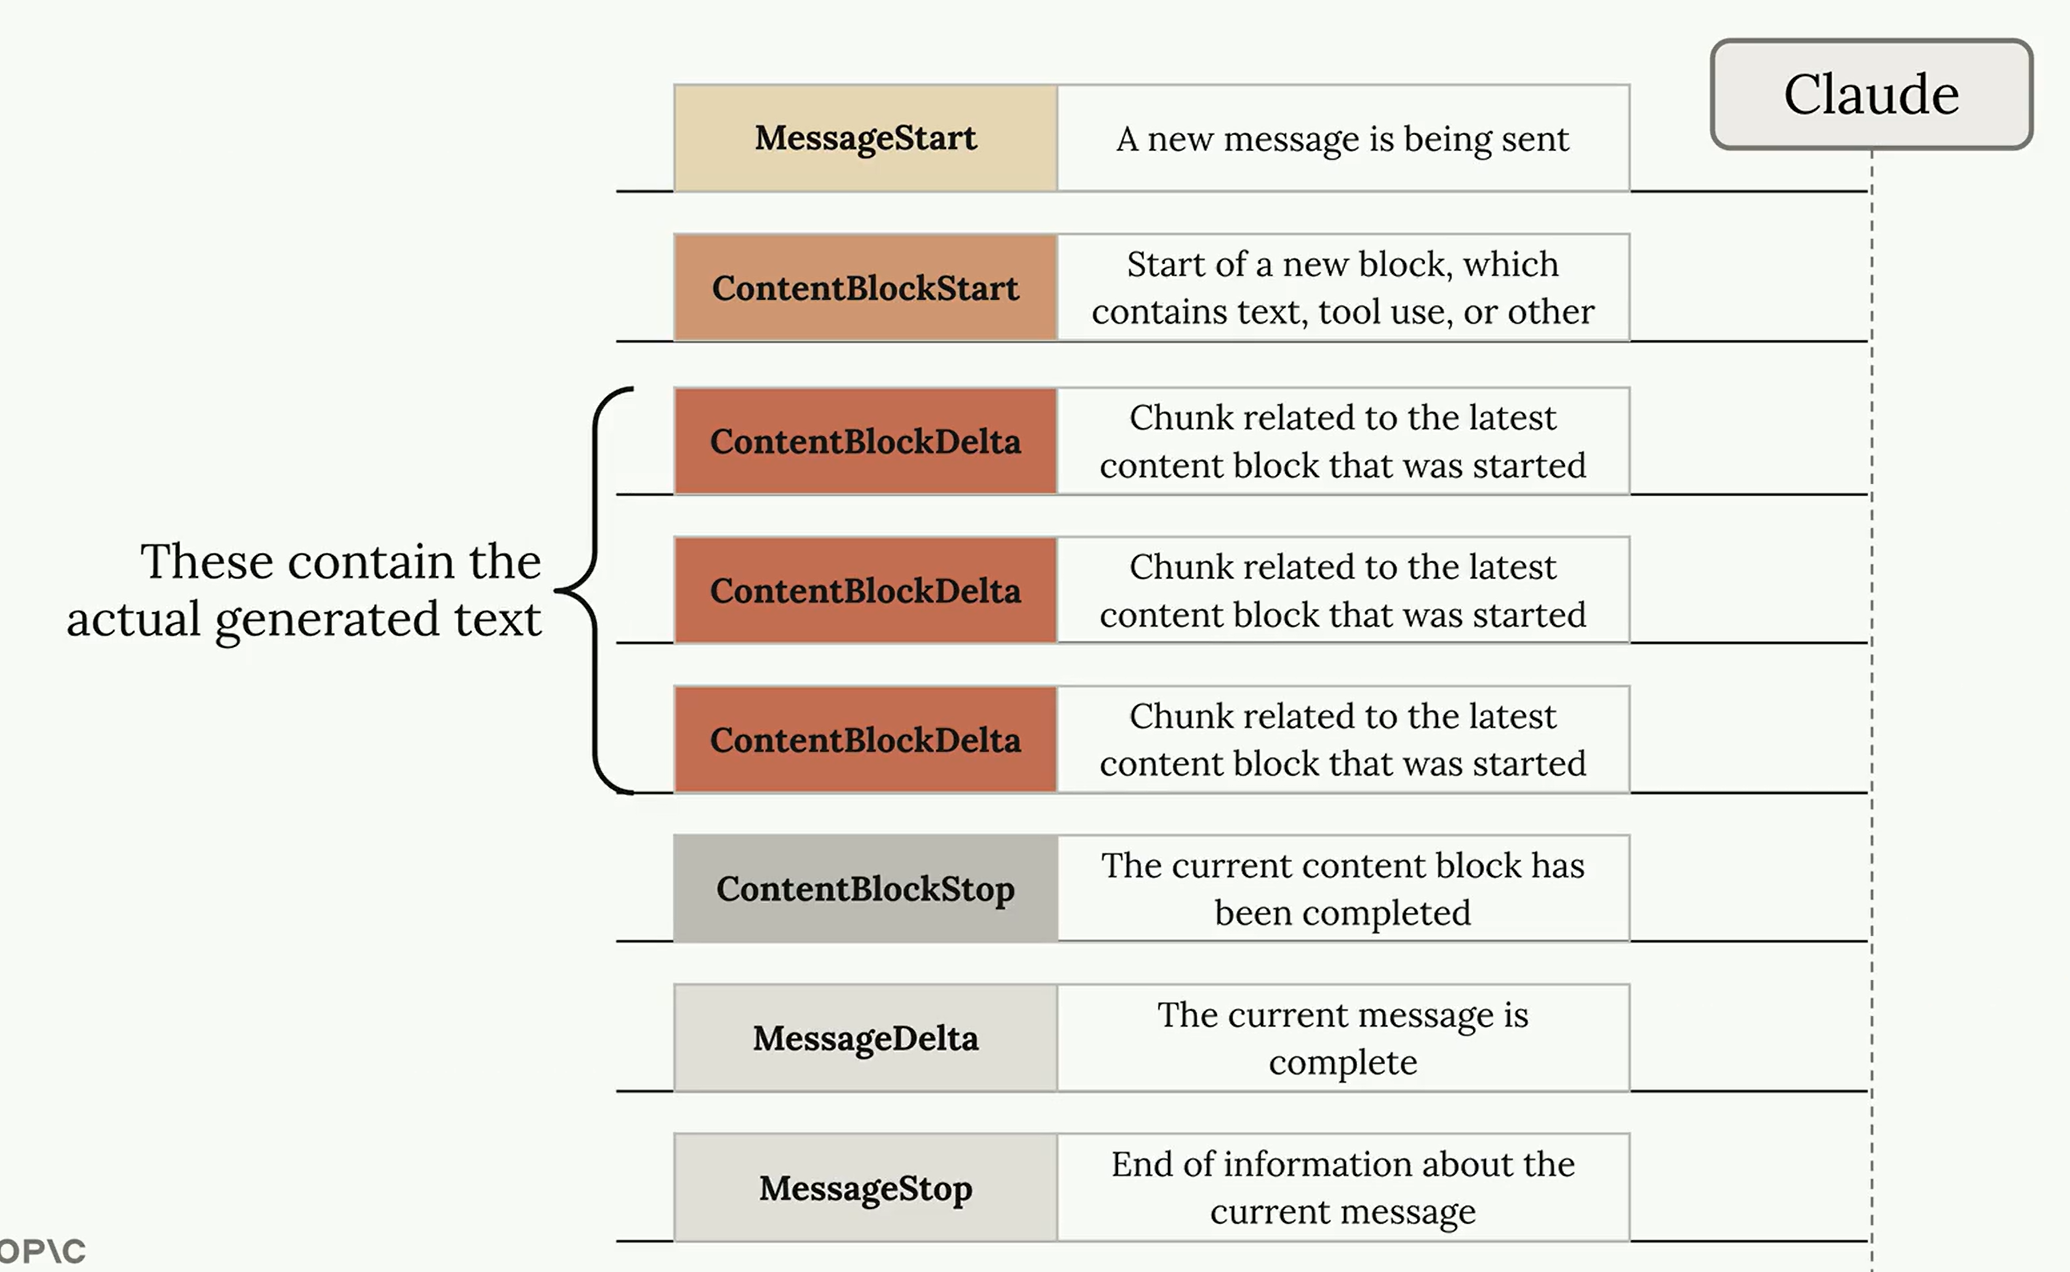

Anthropic SDK gives us a better way to stream responses using `stream.`

In [ ]:
messages = []

add_user_message(messages, "write a 1 sentence description of a fake description")

with client.messages.stream(
    model = model,
    max_tokens = 1000,
    messages = messages
) as stream:
    for text in stream.text_stream:

        #This section prints the response chunks part by part
        #print(text, end ="")# #end="" helps us avoid printing newline characters

        pass
stream.get_final_message() #This returns full message for saving to a database if we want.



# 8. Structured Data

Eventbridge rule generation is an example. Suppose you want it to generate code. But claude goes and talks with regular text in the same response. But you want to just be able to hit the copy button to copy only the code.

In [ ]:
messages = []

add_user_message(messages, "Generate a very short event bridge rule as json")
add_assistant_message(messages, "```json")

text = chat(messages, stop_sequences=["```"])

Give us JSON that we can use for code, but we don't want any other the other extra characters...

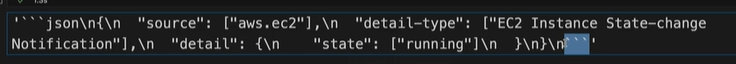

So we're going to do two thigns to refine this:
1. Give an **assistant message**
2. define a **stop sequence**

In [4]:
messages = []

add_user_message(messages, "Generate a very short event bridge rule as json")
add_assistant_message(messages, "```json")

# Every time we see ```, the stop sequence makes it stop generation.`
text = chat(messages, stop_sequences=["```"])

NameError: name 'add_user_message' is not defined

Now we can use json to remove any other content to give us just JSON.

In [ ]:
import json

json.loads(text.strip())

In [ ]:
messages = []

prompt = """Generate three different sample AWS CLI commands. Each should be very short
"""

add_user_message(messages, prompt)

add_assistant_message(messages, "Here are all three commands in a single block without any comments:\n```bash")

text = chat(messages, stop_sequences=["```"])
text.strip()



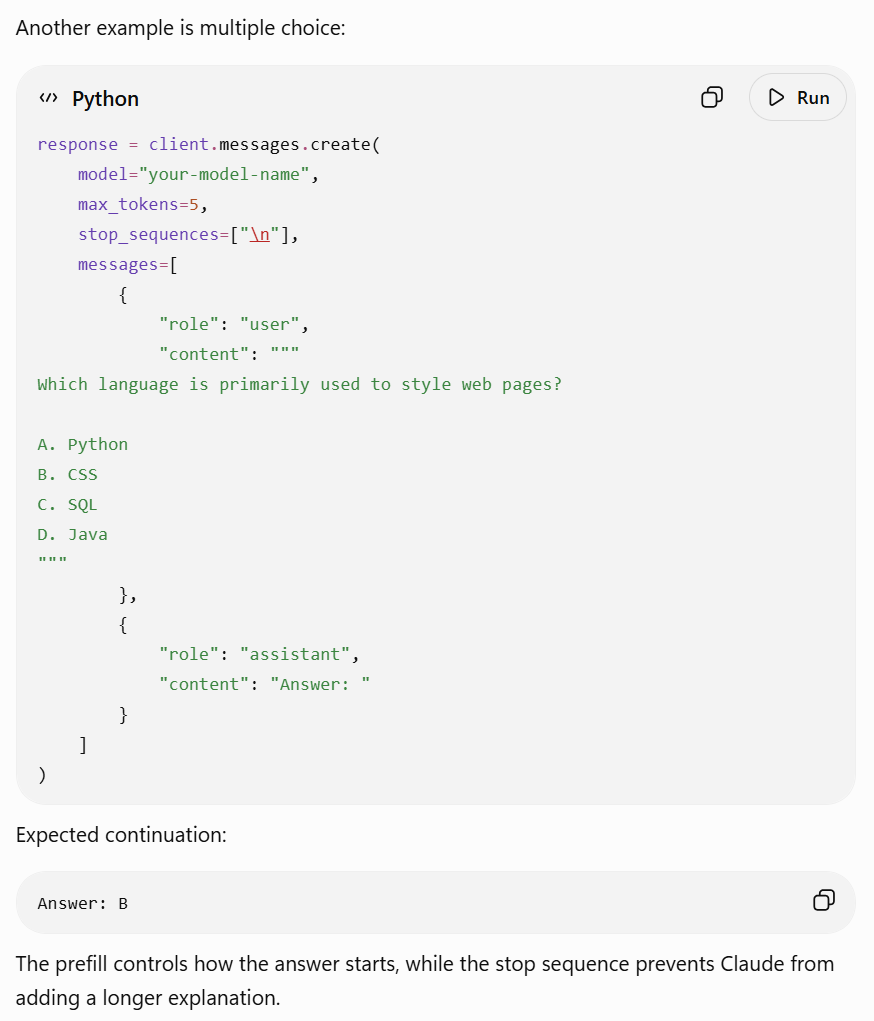